In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('./survey_results.csv')
df.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250
3,R00004,33,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
4,R00005,23,M,Metro,Student,NaN,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100


In [4]:
df.shape

(30010, 17)

In [5]:
df.isnull().sum()

respondent_id                        0
age                                  0
gender                               0
zone                                 0
occupation                           0
income_levels                     8064
consume_frequency(weekly)            8
current_brand                        0
preferable_consumption_size          0
awareness_of_other_brands            0
reasons_for_choosing_brands          0
flavor_preference                    0
purchase_channel                    10
packaging_preference                 0
health_concerns                      0
typical_consumption_situations       0
price_range                          0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(10)

In [7]:
df[df.duplicated()]

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
2309,R02309,27,M,Urban,Working Professional,16L - 25L,3-4 times,Newcomer,Small (250 ml),2 to 4,Brand Reputation,Traditional,Online,Simple,Medium (Moderately health-conscious),Social (eg. Parties),150-200
2666,R02665,61,M,Metro,Entrepreneur,16L - 25L,3-4 times,Established,Medium (500 ml),above 4,Brand Reputation,Exotic,Retail Store,Simple,High (Very health-conscious),"Active (eg. Sports, gym)",200-250
5151,R05149,21,M,Semi-Urban,Student,NaN,3-4 times,Established,Small (250 ml),2 to 4,Availability,Traditional,Retail Store,Simple,Low (Not very concerned),"Active (eg. Sports, gym)",50-100
7794,R07791,25,M,Metro,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150
8516,R08512,20,F,Metro,Student,NaN,5-7 times,Established,Large (1 L),0 to 1,Price,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150
11317,R11312,18,F,Urban,Student,NaN,0-2 times,Newcomer,Medium (500 ml),2 to 4,Availability,Exotic,Online,Premium,Medium (Moderately health-conscious),Social (eg. Parties),100-150
19050,R19044,57,M,Semi-Urban,Retired,<10L,3-4 times,Newcomer,Large (1 L),2 to 4,Price,Traditional,Retail Store,Premium,High (Very health-conscious),Social (eg. Parties),150-200
22412,R22405,26,M,Metro,Working Professional,16L - 25L,0-2 times,Newcomer,Small (250 ml),0 to 1,Price,Exotic,Online,Premium,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
23406,R23398,27,M,Urban,Working Professional,10L - 15L,5-7 times,Newcomer,Large (1 L),above 4,Availability,Traditional,Online,Premium,High (Very health-conscious),Casual (eg. At home),200-250
25068,R25059,34,F,Urban,Working Professional,16L - 25L,0-2 times,Newcomer,Small (250 ml),2 to 4,Brand Reputation,Exotic,Online,Eco-Friendly,High (Very health-conscious),"Active (eg. Sports, gym)",150-200


In [8]:
df1 = df.drop_duplicates()

In [9]:
df1.duplicated().sum()

np.int64(0)

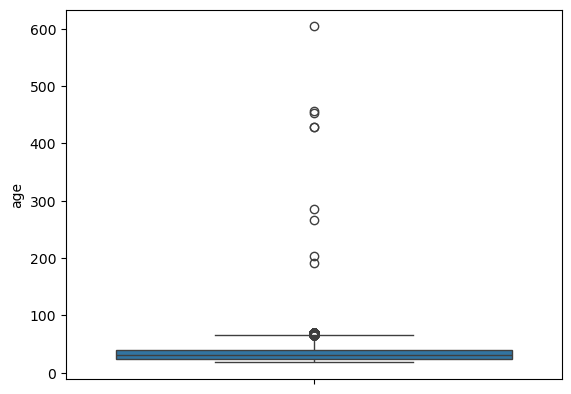

In [10]:
sns.boxplot(df1['age'])
plt.show()

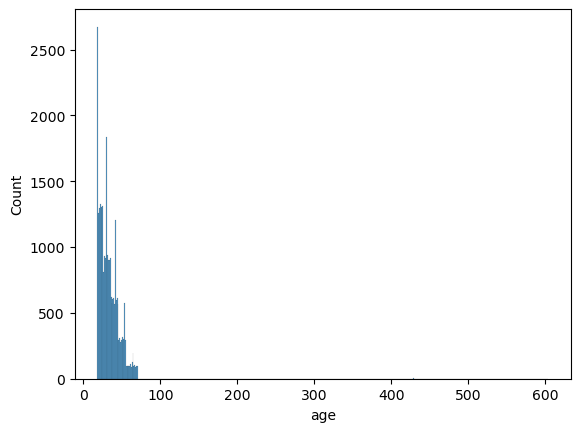

In [11]:
sns.histplot(df['age'])
plt.show()

In [12]:
df1['age'].describe()

count    30000.000000
mean        33.048167
std         13.438904
min         18.000000
25%         23.000000
50%         31.000000
75%         40.000000
max        604.000000
Name: age, dtype: float64

In [13]:
df1['age'].quantile(0.999)

np.float64(70.0)

In [14]:
df2 = df1[df1['age']<=70]

In [15]:
df2.shape

(29991, 17)

<Axes: xlabel='age', ylabel='Count'>

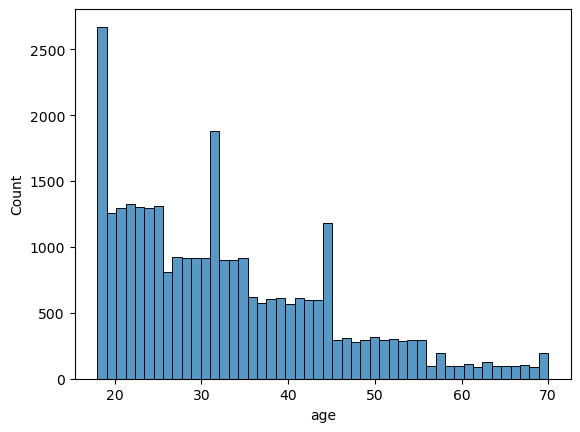

In [16]:
sns.histplot(df2['age'])

# 4:

In [17]:
df2['zone'].unique()

array(['Urban', 'Metro', 'Rural', 'Semi-Urban', 'Metor', 'urbna'],
      dtype=object)

In [18]:
df2['zone'].value_counts()

zone
Metro         11906
Urban         10686
Semi-Urban     5274
Rural          2116
urbna             5
Metor             4
Name: count, dtype: int64

In [19]:
df2['zone'] = df2['zone'].replace({
    'urbna' : 'Urban',
    'Metor' : 'Metro',
})

/var/folders/5z/gtl2866j2q1_wwmwk800t80m0000gn/T/ipykernel_8059/3472748763.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zone'] = df2['zone'].replace({


In [20]:
df2.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250
3,R00004,33,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
4,R00005,23,M,Metro,Student,NaN,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100


In [21]:
df2.shape

(29991, 17)

In [22]:
df2['zone'].unique()

array(['Urban', 'Metro', 'Rural', 'Semi-Urban'], dtype=object)

In [23]:
df2['current_brand'].unique()

array(['Newcomer', 'Established', 'newcomer', 'Establishd'], dtype=object)

In [24]:
df2['current_brand'] = df2['current_brand'].replace({
    'newcomer' : 'Newcomer',
    'Establishd' : 'Established',
})

/var/folders/5z/gtl2866j2q1_wwmwk800t80m0000gn/T/ipykernel_8059/1418228580.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['current_brand'] = df2['current_brand'].replace({


In [25]:
df2.shape

(29991, 17)

In [26]:
df2['current_brand'].unique()

array(['Newcomer', 'Established'], dtype=object)

## 3:

In [27]:
df2['income_levels'].isna().sum()

np.int64(8060)

In [28]:
df2['purchase_channel'].isnull().sum()

np.int64(10)

In [29]:
mode_purchase_channel = df2['purchase_channel'].mode()[0]
mode_purchase_channel

'Online'

In [30]:
df2['purchase_channel'] = df2['purchase_channel'].fillna(mode_purchase_channel)

/var/folders/5z/gtl2866j2q1_wwmwk800t80m0000gn/T/ipykernel_8059/2651196862.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['purchase_channel'] = df2['purchase_channel'].fillna(mode_purchase_channel)


In [31]:
df2['purchase_channel'].isnull().sum()

np.int64(0)

In [32]:
mode_consume_frequencly = df2['consume_frequency(weekly)'].mode()[0]
mode_consume_frequencly

'3-4 times'

In [33]:
df2['consume_frequency(weekly)'].unique()

array(['3-4 times', '5-7 times', '0-2 times', nan], dtype=object)

In [34]:
df2['consume_frequency(weekly)'].isnull().sum()

np.int64(8)

In [35]:
df2['consume_frequency(weekly)'] = df2['consume_frequency(weekly)'].fillna(mode_consume_frequencly)

/var/folders/5z/gtl2866j2q1_wwmwk800t80m0000gn/T/ipykernel_8059/148156639.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['consume_frequency(weekly)'] = df2['consume_frequency(weekly)'].fillna(mode_consume_frequencly)


In [36]:
df2['consume_frequency(weekly)'].isnull().sum()

np.int64(0)

In [37]:
df2.isna().sum()

respondent_id                        0
age                                  0
gender                               0
zone                                 0
occupation                           0
income_levels                     8060
consume_frequency(weekly)            0
current_brand                        0
preferable_consumption_size          0
awareness_of_other_brands            0
reasons_for_choosing_brands          0
flavor_preference                    0
purchase_channel                     0
packaging_preference                 0
health_concerns                      0
typical_consumption_situations       0
price_range                          0
dtype: int64

In [38]:
df2['age'].unique()

array([30, 46, 41, 33, 23, 22, 45, 31, 27, 49, 44, 19, 24, 32, 56, 54, 37,
       63, 52, 40, 35, 21, 34, 26, 18, 20, 25, 39, 53, 28, 59, 36, 50, 29,
       43, 42, 38, 70, 51, 68, 48, 62, 60, 65, 47, 67, 64, 55, 66, 57, 61,
       69, 58])

In [39]:
df2['occupation'].unique()

array(['Working Professional', 'Student', 'Entrepreneur', 'Retired'],
      dtype=object)

In [40]:
df2[df2['occupation'] == 'Student' ].isnull().sum()

respondent_id                        0
age                                  0
gender                               0
zone                                 0
occupation                           0
income_levels                     8060
consume_frequency(weekly)            0
current_brand                        0
preferable_consumption_size          0
awareness_of_other_brands            0
reasons_for_choosing_brands          0
flavor_preference                    0
purchase_channel                     0
packaging_preference                 0
health_concerns                      0
typical_consumption_situations       0
price_range                          0
dtype: int64

In [41]:
df2['income_levels'] = df2['income_levels'].fillna(0)

/var/folders/5z/gtl2866j2q1_wwmwk800t80m0000gn/T/ipykernel_8059/2160725813.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['income_levels'] = df2['income_levels'].fillna(0)


In [42]:
df2.isna().sum()

respondent_id                     0
age                               0
gender                            0
zone                              0
occupation                        0
income_levels                     0
consume_frequency(weekly)         0
current_brand                     0
preferable_consumption_size       0
awareness_of_other_brands         0
reasons_for_choosing_brands       0
flavor_preference                 0
purchase_channel                  0
packaging_preference              0
health_concerns                   0
typical_consumption_situations    0
price_range                       0
dtype: int64

## Feature Engineering:

In [43]:
bin_range = [17,26,36,46,56,71,float('inf')]
bin_labels = ['18-25','26-35','36-45','46-55','56-70','70+']

df2['age_group'] = pd.cut(df2['age'],bins=bin_range,labels= bin_labels)

/var/folders/5z/gtl2866j2q1_wwmwk800t80m0000gn/T/ipykernel_8059/2070647040.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['age_group'] = pd.cut(df2['age'],bins=bin_range,labels= bin_labels)


In [44]:
df2.sample(10)

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group
27140,R27131,41,F,Metro,Working Professional,26L - 35L,5-7 times,Established,Small (250 ml),above 4,Brand Reputation,Exotic,Retail Store,Premium,High (Very health-conscious),Social (eg. Parties),200-250,36-45
5885,R05883,25,M,Semi-Urban,Student,0,5-7 times,Newcomer,Small (250 ml),2 to 4,Availability,Exotic,Retail Store,Simple,High (Very health-conscious),Casual (eg. At home),100-150,18-25
25822,R25813,41,F,Semi-Urban,Entrepreneur,10L - 15L,0-2 times,Newcomer,Medium (500 ml),0 to 1,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,36-45
9709,R09705,21,M,Metro,Student,0,5-7 times,Newcomer,Medium (500 ml),2 to 4,Price,Exotic,Online,Premium,High (Very health-conscious),Social (eg. Parties),150-200,18-25
5787,R05785,29,M,Urban,Working Professional,10L - 15L,3-4 times,Newcomer,Medium (500 ml),above 4,Price,Exotic,Online,Simple,Medium (Moderately health-conscious),Social (eg. Parties),150-200,26-35
28430,R28421,23,M,Urban,Student,0,0-2 times,Established,Medium (500 ml),0 to 1,Price,Traditional,Online,Eco-Friendly,Low (Not very concerned),Casual (eg. At home),50-100,18-25
2023,R02024,20,M,Semi-Urban,Working Professional,10L - 15L,3-4 times,Established,Small (250 ml),0 to 1,Availability,Traditional,Retail Store,Simple,Low (Not very concerned),Social (eg. Parties),50-100,18-25
15518,R15513,42,F,Metro,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Availability,Traditional,Online,Simple,Low (Not very concerned),Social (eg. Parties),100-150,36-45
9373,R09369,34,M,Urban,Student,0,0-2 times,Established,Medium (500 ml),0 to 1,Availability,Exotic,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35
5569,R05567,33,F,Urban,Entrepreneur,16L - 25L,3-4 times,Established,Small (250 ml),2 to 4,Brand Reputation,Traditional,Retail Store,Eco-Friendly,High (Very health-conscious),Social (eg. Parties),200-250,26-35


In [45]:
df2.columns

Index(['respondent_id', 'age', 'gender', 'zone', 'occupation', 'income_levels',
       'consume_frequency(weekly)', 'current_brand',
       'preferable_consumption_size', 'awareness_of_other_brands',
       'reasons_for_choosing_brands', 'flavor_preference', 'purchase_channel',
       'packaging_preference', 'health_concerns',
       'typical_consumption_situations', 'price_range', 'age_group'],
      dtype='object')

In [46]:
df2['age_group'].unique()

['26-35', '36-45', '18-25', '46-55', '56-70']
Categories (6, object): ['18-25' < '26-35' < '36-45' < '46-55' < '56-70' < '70+']

In [47]:
df2[df2['age_group'].isnull()]['age']

Series([], Name: age, dtype: int64)

In [48]:
df3 = df2.copy()

In [49]:
df3.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,36-45
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250,36-45
3,R00004,33,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200,26-35
4,R00005,23,M,Metro,Student,0,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100,18-25


## 2

In [50]:
df3['consume_frequency(weekly)'].unique()

array(['3-4 times', '5-7 times', '0-2 times'], dtype=object)

In [51]:
df3['consume_frequency(weekly)'] = df3['consume_frequency(weekly)'].replace({
    '0-2 times' : 1,
    '3-4 times' : 2,
    '5-7 times' : 3
})

/var/folders/5z/gtl2866j2q1_wwmwk800t80m0000gn/T/ipykernel_8059/146369923.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df3['consume_frequency(weekly)'] = df3['consume_frequency(weekly)'].replace({


In [52]:
df3['consume_frequency(weekly)'].unique()

array([2, 3, 1])

In [53]:
df3.head(2)

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group
0,R00001,30,M,Urban,Working Professional,<10L,2,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35
1,R00002,46,F,Metro,Working Professional,> 35L,3,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,36-45


In [54]:
df3['awareness_of_other_brands'].unique()

array(['0 to 1', '2 to 4', 'above 4'], dtype=object)

In [55]:
df3['awareness_of_other_brands'] = df3['awareness_of_other_brands'].replace({
    '0 to 1' : 1,
    '2 to 4' : 2,
    'above 4' : 3
})

/var/folders/5z/gtl2866j2q1_wwmwk800t80m0000gn/T/ipykernel_8059/1317005265.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df3['awareness_of_other_brands'] = df3['awareness_of_other_brands'].replace({


In [56]:
df3['awareness_of_other_brands'].unique()

array([1, 2, 3])

In [57]:
df3['cf_ab_score'] = (df3['consume_frequency(weekly)']/(df3['awareness_of_other_brands'] + df3['consume_frequency(weekly)'])).round(2)

In [58]:
df3[['consume_frequency(weekly)','awareness_of_other_brands','cf_ab_score']].head()

,consume_frequency(weekly),awareness_of_other_brands,cf_ab_score
0,2,1,0.67
1,3,2,0.60
2,2,2,0.50
3,3,1,0.75
4,2,1,0.67


In [59]:
df3['cf_ab_score'].max()

0.75

## 3

In [60]:
df3['zone'].unique()

array(['Urban', 'Metro', 'Rural', 'Semi-Urban'], dtype=object)

In [61]:
df3['zone'] = df3['zone'].replace({
    'Urban' : 3,
    'Metro' : 4,
    'Rural' : 1,
    'Semi-Urban' : 2
})

/var/folders/5z/gtl2866j2q1_wwmwk800t80m0000gn/T/ipykernel_8059/183242519.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df3['zone'] = df3['zone'].replace({


In [62]:
df3['zone'].unique()

array([3, 4, 1, 2])

In [63]:
df3['income_levels'] = df3['income_levels'].replace({
    '<10L' : 1,
    '10L - 15L' : 2,
    '16L - 25L' : 3,
    '26L - 35L' : 4,
    '> 35L' : 5,
    'Not Reported' : 0
})

/var/folders/5z/gtl2866j2q1_wwmwk800t80m0000gn/T/ipykernel_8059/1743103930.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df3['income_levels'] = df3['income_levels'].replace({


In [64]:
df3['income_levels'].unique()

array([1, 5, 3, 0, 2, 4])

In [65]:
df3['zas_score'] = df3['zone'] * df3['income_levels']

In [66]:
df3.head(2)

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group,cf_ab_score,zas_score
0,R00001,30,M,3,Working Professional,1,2,Newcomer,Medium (500 ml),1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35,0.67,3
1,R00002,46,F,4,Working Professional,5,3,Established,Medium (500 ml),2,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,36-45,0.60,20


In [67]:
len(df3['zas_score'].unique())

14

## 4

In [68]:
def assign_bsi_value(df):
    if df['current_brand'] != 'Established' and df['reasons_for_choosing_brands'] in ['Price','Quality']:
        return 1
    else :
        return 0

In [69]:
df3['bsi'] = 0

In [70]:
df3.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,...,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group,cf_ab_score,zas_score,bsi
0,R00001,30,M,3,Working Professional,1,2,Newcomer,Medium (500 ml),1,...,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35,0.67,3,0
1,R00002,46,F,4,Working Professional,5,3,Established,Medium (500 ml),2,...,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,36-45,0.60,20,0
2,R00003,41,F,1,Working Professional,5,2,Newcomer,Medium (500 ml),2,...,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250,36-45,0.50,5,0
3,R00004,33,F,3,Working Professional,3,3,Newcomer,Medium (500 ml),1,...,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200,26-35,0.75,9,0
4,R00005,23,M,4,Student,0,2,Established,Medium (500 ml),1,...,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100,18-25,0.67,0,0


In [71]:
df3['bsi'] = df3.apply(assign_bsi_value, axis=1)

In [72]:
df3[df3['age'] == 18]

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,...,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group,cf_ab_score,zas_score,bsi
34,R00035,18,M,4,Student,0,2,Newcomer,Large (1 L),1,...,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),100-150,18-25,0.67,0,1
43,R00044,18,M,4,Student,0,2,Established,Large (1 L),2,...,Exotic,Retail Store,Premium,Low (Not very concerned),Casual (eg. At home),100-150,18-25,0.50,0,0
51,R00052,18,F,2,Student,0,3,Newcomer,Large (1 L),1,...,Traditional,Retail Store,Simple,Low (Not very concerned),Casual (eg. At home),50-100,18-25,0.75,0,1
61,R00062,18,M,3,Student,0,3,Established,Medium (500 ml),1,...,Traditional,Online,Premium,Low (Not very concerned),"Active (eg. Sports, gym)",100-150,18-25,0.75,0,0
149,R00150,18,F,4,Student,0,1,Established,Medium (500 ml),1,...,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100,18-25,0.50,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29918,R29909,18,M,2,Student,0,1,Newcomer,Medium (500 ml),1,...,Traditional,Retail Store,Simple,Low (Not very concerned),Casual (eg. At home),50-100,18-25,0.50,0,1
29931,R29922,18,F,4,Student,0,3,Established,Large (1 L),2,...,Exotic,Online,Simple,Medium (Moderately health-conscious),Social (eg. Parties),100-150,18-25,0.60,0,0
29946,R29937,18,F,2,Student,0,3,Newcomer,Medium (500 ml),1,...,Exotic,Retail Store,Premium,Low (Not very concerned),Casual (eg. At home),50-100,18-25,0.75,0,0
29950,R29941,18,M,3,Student,0,1,Newcomer,Small (250 ml),2,...,Traditional,Online,Premium,Low (Not very concerned),"Active (eg. Sports, gym)",100-150,18-25,0.33,0,1


In [73]:
df3.shape

(29991, 21)

In [74]:
df3[(df3['age_group']== '56-70') & (df3['occupation'] == 'Student')].shape

(34, 21)

In [75]:
df3.shape

(29991, 21)

In [76]:
df3[df3['age']>70]

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,...,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group,cf_ab_score,zas_score,bsi


In [77]:
df4 = df3.copy()

In [78]:
df4.drop(df4[(df4['age_group']== '56-70') & (df4['occupation'] == 'Student')].index,axis=0,inplace=True)

In [79]:
df4.shape

(29957, 21)

## 5

In [80]:
df4['bsi'].value_counts()

bsi
0    20797
1     9160
Name: count, dtype: int64

## Encoding:

In [81]:
df4['age_group'].unique()

['26-35', '36-45', '18-25', '46-55', '56-70']
Categories (6, object): ['18-25' < '26-35' < '36-45' < '46-55' < '56-70' < '70+']

In [82]:
df4['age_group'] = df4['age_group'].cat.codes

In [83]:
df4['age_group'].unique()

array([1, 2, 0, 3, 4], dtype=int8)

In [84]:
df4['income_levels'].unique()

array([1, 5, 3, 0, 2, 4])

In [85]:
df4['health_concerns'].unique()

array(['Medium (Moderately health-conscious)', 'Low (Not very concerned)',
       'High (Very health-conscious)'], dtype=object)

In [86]:
df4['health_concerns'] = df4['health_concerns'].replace({
    'Medium (Moderately health-conscious)' : 2, 
    'Low (Not very concerned)' : 1 ,
    'High (Very health-conscious)' : 3
})

/var/folders/5z/gtl2866j2q1_wwmwk800t80m0000gn/T/ipykernel_8059/1334662616.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df4['health_concerns'] = df4['health_concerns'].replace({


In [87]:
df4['health_concerns'].unique()

array([2, 1, 3])

In [88]:
df4['consume_frequency(weekly)'].unique()

array([2, 3, 1])

In [89]:
df4['preferable_consumption_size'].unique()

array(['Medium (500 ml)', 'Large (1 L)', 'Small (250 ml)'], dtype=object)

In [90]:
df4['preferable_consumption_size'] = df4['preferable_consumption_size'].replace({
    'Medium (500 ml)':2, 
    'Large (1 L)':3, 
    'Small (250 ml)':1
})

/var/folders/5z/gtl2866j2q1_wwmwk800t80m0000gn/T/ipykernel_8059/253465091.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df4['preferable_consumption_size'] = df4['preferable_consumption_size'].replace({


In [91]:
df4['price_range'].unique()

array(['100-150', '200-250', '150-200', '50-100'], dtype=object)

In [92]:
df4['price_range'] = df4['price_range'].replace({
    '50-100' : 1,
    '100-150' :2, 
    '150-200' :3,
    '200-250' :4,
})

/var/folders/5z/gtl2866j2q1_wwmwk800t80m0000gn/T/ipykernel_8059/2517219268.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df4['price_range'] = df4['price_range'].replace({


In [93]:
df4['price_range'].unique()

array([2, 4, 3, 1])

In [94]:
df4.head(2)

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,...,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group,cf_ab_score,zas_score,bsi
0,R00001,30,M,3,Working Professional,1,2,Newcomer,2,1,...,Traditional,Online,Simple,2,"Active (eg. Sports, gym)",2,1,0.67,3,1
1,R00002,46,F,4,Working Professional,5,3,Established,2,2,...,Exotic,Retail Store,Premium,2,Social (eg. Parties),4,2,0.60,20,0


In [95]:
df4['income_levels'].unique()

array([1, 5, 3, 0, 2, 4])

In [96]:
one_hot_encode_cols = ['gender','occupation','current_brand','reasons_for_choosing_brands','flavor_preference','purchase_channel','packaging_preference','typical_consumption_situations']

In [97]:
df5 = pd.get_dummies(data = df4,columns=one_hot_encode_cols,drop_first=True,dtype=int)

In [98]:
df5

,respondent_id,age,zone,income_levels,consume_frequency(weekly),preferable_consumption_size,awareness_of_other_brands,health_concerns,price_range,age_group,...,current_brand_Newcomer,reasons_for_choosing_brands_Brand Reputation,reasons_for_choosing_brands_Price,reasons_for_choosing_brands_Quality,flavor_preference_Traditional,purchase_channel_Retail Store,packaging_preference_Premium,packaging_preference_Simple,typical_consumption_situations_Casual (eg. At home),typical_consumption_situations_Social (eg. Parties)
0,R00001,30,3,1,2,2,1,2,2,1,...,1,0,1,0,1,0,0,1,0,0
1,R00002,46,4,5,3,2,2,2,4,2,...,0,0,0,1,0,1,1,0,0,1
2,R00003,41,1,5,2,2,2,2,4,2,...,1,0,0,0,1,1,1,0,0,0
3,R00004,33,3,3,3,2,1,1,3,1,...,1,1,0,0,0,0,0,0,0,0
4,R00005,23,4,0,2,2,1,2,1,0,...,0,0,0,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30005,R29996,29,4,3,2,2,2,3,3,1,...,1,0,0,0,1,0,0,1,0,1
30006,R29997,42,3,5,2,1,2,1,4,2,...,0,0,0,1,1,0,1,0,0,0
30007,R29998,57,4,1,1,2,1,3,3,4,...,0,0,1,0,1,1,1,0,1,0
30008,R29999,23,3,3,3,1,3,2,3,0,...,0,0,0,1,0,0,0,0,0,1


## Predictive Modeling

In [99]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [100]:
df5 = df5.drop(['age','respondent_id'],axis=1)

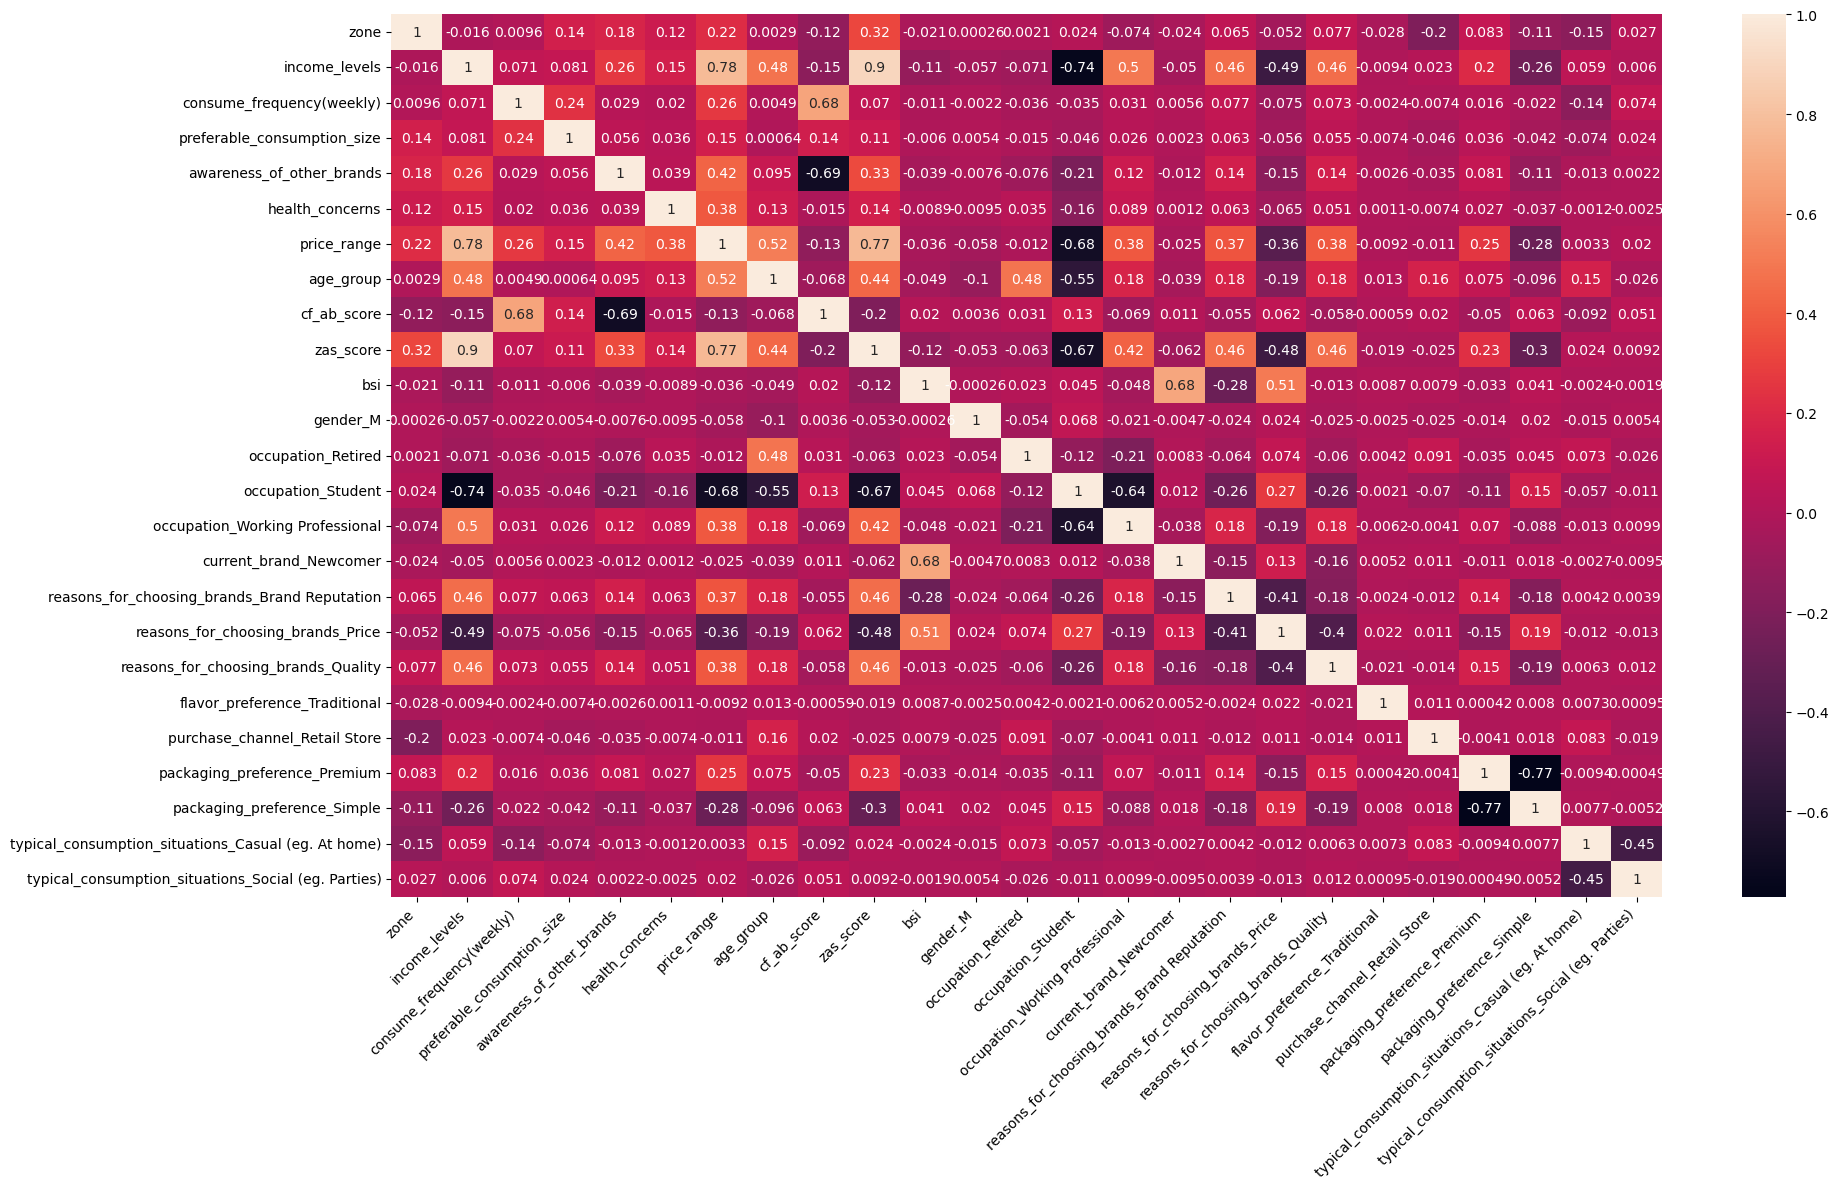

In [101]:
cm = df5.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [102]:
X = df5.drop('price_range',axis=1)
y = df5['price_range']

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [104]:
X_train = X_train.copy()
X_test = X_test.copy()

In [105]:
cols_to_scale = ['zas_score', 'cf_ab_score']
scaler = MinMaxScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

## Logistic Regression:

In [129]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import mlflow
import mlflow.sklearn

# Encode labels 
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

# Define hyperparameters
params = {
    "solver": "lbfgs",
    "max_iter": 1000,
    "multi_class": "multinomial",
    "random_state": 8888,
}

# Train model
lr = LogisticRegression(**params)

lr.fit(X_train, y_train_encoded)

# Predictions
y_pred = lr.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred, average='weighted')
recall = recall_score(y_test_encoded, y_pred, average='weighted')
f1 = f1_score(y_test_encoded, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_encoded, y_pred))


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.8332443257676903
Precision: 0.8338759339246354
Recall: 0.8332443257676903
F1 Score: 0.8333888077494083

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.80      0.83       935
           1       0.78      0.80      0.79      1903
           2       0.79      0.79      0.79      2211
           3       0.91      0.91      0.91      2441

    accuracy                           0.83      7490
   macro avg       0.83      0.83      0.83      7490
weighted avg       0.83      0.83      0.83      7490


Confusion Matrix:

[[ 748  187    0    0]
 [ 124 1530  249    0]
 [   0  244 1744  223]
 [   0    0  222 2219]]


In [130]:
score = lr.score(X_test,y_test_encoded)
print(score)

0.8332443257676903


In [132]:
# MLflow Tracking
mlflow.set_experiment("Beverage_price_prediction")
mlflow.set_tracking_uri("http://127.0.0.1:5000/")

with mlflow.start_run(run_name="Logistic_Regression"):

    # Tags
    mlflow.set_tag("algorithm", "LogisticRegression")
    mlflow.set_tag("type", "Multiclass Classification")

    # Parameters
    mlflow.log_params(params)

    # Metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # Log model
    mlflow.sklearn.log_model(lr, "logistic_regression_model")

print("Model and metrics logged successfully!")

2026/05/09 11:53:39 INFO mlflow.tracking.fluent: Experiment with name 'Beverage_price_prediction' does not exist. Creating a new experiment.
2026/05/09 11:53:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 11:53:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Logistic_Regression at: http://127.0.0.1:5000/#/experiments/6/runs/9bcdf02b1d2941e8bfe0ff2c6d61fe16
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
Model and metrics logged successfully!


In [109]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29957 entries, 0 to 30009
Data columns (total 25 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   zone                                                 29957 non-null  int64  
 1   income_levels                                        29957 non-null  int64  
 2   consume_frequency(weekly)                            29957 non-null  int64  
 3   preferable_consumption_size                          29957 non-null  int64  
 4   awareness_of_other_brands                            29957 non-null  int64  
 5   health_concerns                                      29957 non-null  int64  
 6   price_range                                          29957 non-null  int64  
 7   age_group                                            29957 non-null  int8   
 8   cf_ab_score                                          29957 non-null  fl

## SVC model

In [136]:
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import mlflow
import mlflow.sklearn

# Encode labels
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

# Model
model_svc = SVC(
    C=1.0,
    kernel='linear',
    gamma='scale',
    random_state=42
)

# Train
model_svc.fit(X_train, y_train_encoded)

# Predict
y_pred = model_svc.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred, average='weighted')
recall = recall_score(y_test_encoded, y_pred, average='weighted')
f1 = f1_score(y_test_encoded, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_encoded, y_pred))


Accuracy: 0.8335113484646195
Precision: 0.8342730728350577
Recall: 0.8335113484646195
F1 Score: 0.8337437550047931

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.80      0.83       935
           1       0.78      0.80      0.79      1903
           2       0.79      0.79      0.79      2211
           3       0.91      0.91      0.91      2441

    accuracy                           0.83      7490
   macro avg       0.83      0.83      0.83      7490
weighted avg       0.83      0.83      0.83      7490


Confusion Matrix:

[[ 751  184    0    0]
 [ 125 1525  253    0]
 [   0  243 1752  216]
 [   0    0  226 2215]]


In [137]:
# MLflow Tracking
mlflow.set_experiment("Beverage_price_prediction")

with mlflow.start_run(run_name="SVC_Multiclass"):

    # Parameters
    mlflow.log_params(model_svc.get_params())

    # Metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # Log model
    mlflow.sklearn.log_model(model_svc, "svc_model")

print("Model and metrics logged successfully!")

2026/05/09 11:56:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 11:56:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run SVC_Multiclass at: http://127.0.0.1:5000/#/experiments/6/runs/ad37f6e07bc04f36bda223f12670647a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
Model and metrics logged successfully!


## Random Forest model:

In [138]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import mlflow
import mlflow.sklearn

# Model
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# Train
model_rf.fit(X_train, y_train)

# Predict
y_pred = model_rf.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print Metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8969292389853137
Precision: 0.8976802090131228
Recall: 0.8969292389853137
F1 Score: 0.8971908188199825

Classification Report:

              precision    recall  f1-score   support

           1       0.93      0.89      0.91       935
           2       0.88      0.88      0.88      1903
           3       0.85      0.88      0.86      2211
           4       0.94      0.93      0.94      2441

    accuracy                           0.90      7490
   macro avg       0.90      0.89      0.90      7490
weighted avg       0.90      0.90      0.90      7490


Confusion Matrix:

[[ 835  100    0    0]
 [  60 1674  169    0]
 [   0  135 1936  140]
 [   0    0  168 2273]]


In [139]:
# MLflow Logging
mlflow.set_experiment("Beverage_price_prediction")

with mlflow.start_run(run_name="RandomForestClassifier"):

    # Log Parameters
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", None)
    mlflow.log_param("min_samples_split", 2)
    mlflow.log_param("min_samples_leaf", 1)

    # Log Metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # Log Model
    mlflow.sklearn.log_model(model_rf, "random_forest_classifier")

print("Model and metrics logged to MLflow successfully!")

2026/05/09 11:56:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 11:56:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RandomForestClassifier at: http://127.0.0.1:5000/#/experiments/6/runs/414e194937ab4332938c61b1f5a87f95
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
Model and metrics logged to MLflow successfully!


In [114]:
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

## XGB model

In [140]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import mlflow
import mlflow.xgboost

# Encode labels
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

# Parameter grid
params = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
}

# Base model
xgb_model = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)

# Hyperparameter tuning
search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=params,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Train
search.fit(X_train, y_train_encoded)

# Best model
best_model = search.best_estimator_

print("Best Parameters:", search.best_params_)
print("Best CV Score:", search.best_score_)

# Predictions
y_pred = best_model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred, average='weighted')
recall = recall_score(y_test_encoded, y_pred, average='weighted')
f1 = f1_score(y_test_encoded, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_encoded, y_pred))

Best Parameters: {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05}
Best CV Score: 0.9098678061156363
Accuracy: 0.9185580774365821
Precision: 0.9187089264689458
Recall: 0.9185580774365821
F1 Score: 0.9186138019074314

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       935
           1       0.90      0.90      0.90      1903
           2       0.89      0.90      0.90      2211
           3       0.95      0.95      0.95      2441

    accuracy                           0.92      7490
   macro avg       0.92      0.92      0.92      7490
weighted avg       0.92      0.92      0.92      7490


Confusion Matrix:

[[ 852   83    0    0]
 [  63 1722  118    0]
 [   0  107 1988  116]
 [   0    0  123 2318]]


In [141]:
mlflow.set_experiment("Beverage_price_prediction")

with mlflow.start_run(run_name="XGBoost_Classifier"):

    mlflow.log_params(search.best_params_)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    mlflow.xgboost.log_model(best_model, "xgboost_classifier")

print("Model and metrics logged successfully!")

2026/05/09 11:57:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBoost_Classifier at: http://127.0.0.1:5000/#/experiments/6/runs/55952767862b479f88063f4e05b3fef5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
Model and metrics logged successfully!


## LightBGM model

In [142]:
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import mlflow
import mlflow.lightgbm

# Encode labels 
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

# Model
model_lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    num_leaves=31,
    random_state=42
)

# Train
model_lgbm.fit(X_train, y_train_encoded)

# Predict
y_pred = model_lgbm.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred, average='weighted')
recall = recall_score(y_test_encoded, y_pred, average='weighted')
f1 = f1_score(y_test_encoded, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred))

# Confusion Matrix"
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_encoded, y_pred))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000939 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 83
[LightGBM] [Info] Number of data points in the train set: 22467, number of used features: 24
[LightGBM] [Info] Start training from score -2.111416
[LightGBM] [Info] Start training from score -1.338622
[LightGBM] [Info] Start training from score -1.227101
[LightGBM] [Info] Start training from score -1.128291
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Accuracy: 0.9076101468624833
Precision: 0.9083410673641369
Recall: 0.9076101468624833
F1 Score: 0.9078539489483163

Classificati

In [143]:
# MLflow Logging
mlflow.set_experiment("Beverage_price_prediction")

with mlflow.start_run(run_name="LightGBM_Classifier"):

    # Log Parameters
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("num_leaves", 31)

    # Log Metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # Log Model
    mlflow.lightgbm.log_model(model_lgbm, "lightgbm_classifier")

print("Model and metrics logged to MLflow successfully!")

2026/05/09 11:57:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 11:57:33 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LightGBM_Classifier at: http://127.0.0.1:5000/#/experiments/6/runs/7271c5171559470f857e6d431e80dc32
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
Model and metrics logged to MLflow successfully!


## Gaussian NB Model

In [144]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import mlflow
import mlflow.sklearn

# Encode labels 
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

# Model
model_nb = GaussianNB(
    var_smoothing=1e-9
)

# Train
model_nb.fit(X_train, y_train_encoded)

# Predict
y_pred = model_nb.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred, average='weighted')
recall = recall_score(y_test_encoded, y_pred, average='weighted')
f1 = f1_score(y_test_encoded, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_encoded, y_pred))


Accuracy: 0.5688918558077437
Precision: 0.566985133458729
Recall: 0.5688918558077437
F1 Score: 0.5319592594841165

Classification Report:

              precision    recall  f1-score   support

           0       0.44      0.92      0.59       935
           1       0.48      0.28      0.35      1903
           2       0.58      0.30      0.40      2211
           3       0.67      0.90      0.77      2441

    accuracy                           0.57      7490
   macro avg       0.54      0.60      0.53      7490
weighted avg       0.57      0.57      0.53      7490


Confusion Matrix:

[[ 860   61   11    3]
 [ 943  530  278  152]
 [ 157  477  663  914]
 [   0   44  189 2208]]


In [145]:
# MLflow setup
mlflow.set_experiment("Beverage_price_prediction")
mlflow.set_tracking_uri("http://127.0.0.1:5000/")

with mlflow.start_run(run_name="Gaussian_Naive_Bayes"):

    # Tags
    mlflow.set_tag(
        "description",
        "Gaussian Naive Bayes multiclass classification model."
    )

    mlflow.set_tag("algorithm", "GaussianNB")
    mlflow.set_tag("type", "Multiclass Classification")

    # Parameters
    mlflow.log_param("model", "GaussianNB")
    mlflow.log_params(model_nb.get_params())

    # Metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # Log Model
    mlflow.sklearn.log_model(model_nb, "gaussian_nb_model")

print("Model and metrics logged successfully!")

2026/05/09 11:57:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 11:57:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Gaussian_Naive_Bayes at: http://127.0.0.1:5000/#/experiments/6/runs/efc8da68bc3f4a9a98e84baead5b2b77
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
Model and metrics logged successfully!
